### Goal:
Predict individual medical costs billed by health insurance based on patient attributes

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# Load data
df = pd.read_csv(r"C:\Users\Антон\OneDrive\Документы\Machine Learning\Projects\linear_regression\data\insurance.csv")

In [4]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


#### EDA

The dataset contains the following features:

- Age: Age of primary beneficiary
- Sex: Insurance contractor gender(female/male)
- BMI: Body mass index(($kg/m^2$))
- Children: Number of children coveref by health insurance
- Smoker: Smoking status(yes/no)
- Region: Recidential area of the beneficiary(US)
- Charnges: individual medical costs billed by health insurance(Our Target)

Let`s check the smoker factor first. We want to see how age affects cost, but we suspect that smoking status creates visible split in the data

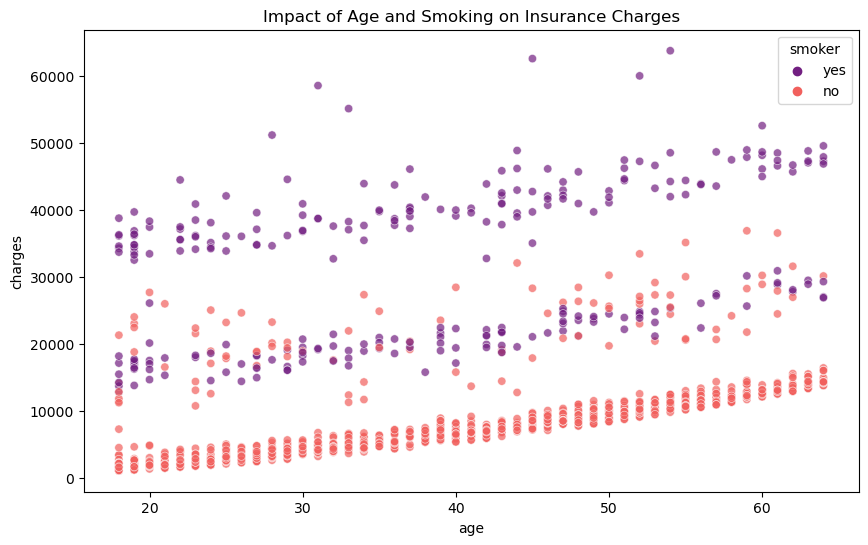

In [24]:
# Visualizing Age vs Charges, separated by Smoker status
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='magma', alpha=0.7)
plt.title('Impact of Age and Smoking on Insurance Charges')
plt.show()

As expected data  split in a three distinct tiers:  

- The bottom line: Non-Smokers. Their costs increase very slowly and linearly over aging
- The middle and Top Lines: Smokers. Even 20 year-old smoker might have  higher charges than 60 years old non-smoker. 

Let`s look at bmi and charger correlation next:

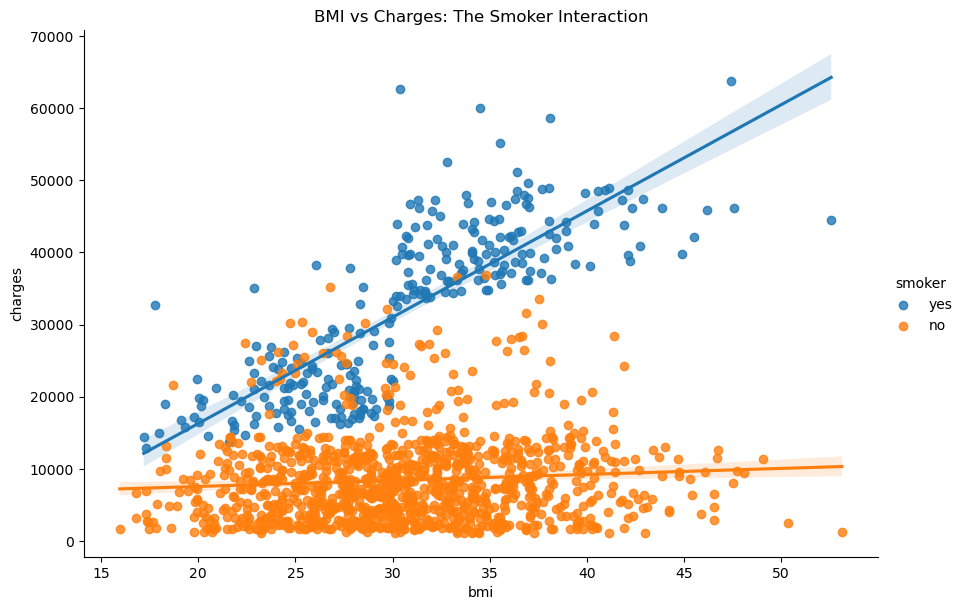

In [25]:
# Interaction between BMI and Smoking
sns.lmplot(data=df, x='bmi', y='charges', hue='smoker', aspect=1.5, height=6)
plt.title('BMI vs Charges: The Smoker Interaction')
plt.show()

Insights:  

- For non-smokers, the line is almost flat. A high BMI doesn`t necessarily mean high  insurance bills
- For smokers, the line has a steep uppward slope, which could mean that high BMI combined with smoking is what drives the massive charges 

In [28]:
# basic preprocessing
df['smoker'] = df['smoker'].map({'yes': 1, 'no': 0})
df = pd.get_dummies(df, columns=['region', 'sex'], drop_first=True)

In [29]:
df

,age,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,sex_male
0,19,27.900,0,1,16884.92400,False,False,True,False
1,18,33.770,1,0,1725.55230,False,True,False,True
2,28,33.000,3,0,4449.46200,False,True,False,True
3,33,22.705,0,0,21984.47061,True,False,False,True
4,32,28.880,0,0,3866.85520,True,False,False,True
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,10600.54830,True,False,False,True
1334,18,31.920,0,0,2205.98080,False,False,False,False
1335,18,36.850,0,0,1629.83350,False,True,False,False
1336,21,25.800,0,0,2007.94500,False,False,True,False


#### Correlation Matrix

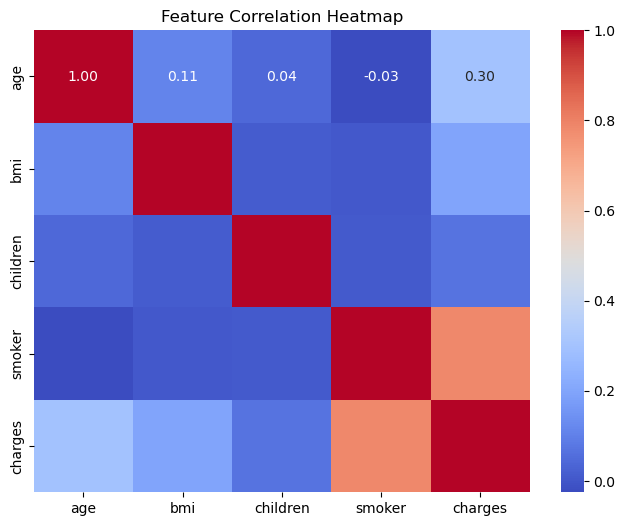

In [30]:
# Correlation Heatmap
# Note: We must convert categorical strings to numbers first
corr = df.select_dtypes(include=['number']).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

In [31]:
corr

,age,bmi,children,smoker,charges
age,1.000000,0.109272,0.042469,-0.025019,0.299008
bmi,0.109272,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.198341,0.067998,0.787251,1.000000


Summary:  

- The relationship with Age is quite linear
- Smoking  isn`t just a 'minor detail' - it's the dominant signal

In [32]:
# Split Data
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

,age,bmi,children,smoker,region_northwest,region_southeast,region_southwest,sex_male
0,19,27.900,0,1,False,False,True,False
1,18,33.770,1,0,False,True,False,True
2,28,33.000,3,0,False,True,False,True
3,33,22.705,0,0,True,False,False,True
4,32,28.880,0,0,True,False,False,True
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,True,False,False,True
1334,18,31.920,0,0,False,False,False,False
1335,18,36.850,0,0,False,True,False,False
1336,21,25.800,0,0,False,False,True,False


### Training Model

In [34]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### Evaluation

In [39]:
predictions = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, predictions)}")
# print(f'RMSE: {mean_squared_error(y_test, predictions, squared=False)}')
# print(f'MAE: {mean_absolute_error(y_test, predictions)}')

R2 Score: 0.7835929767120724


#### Residual plot

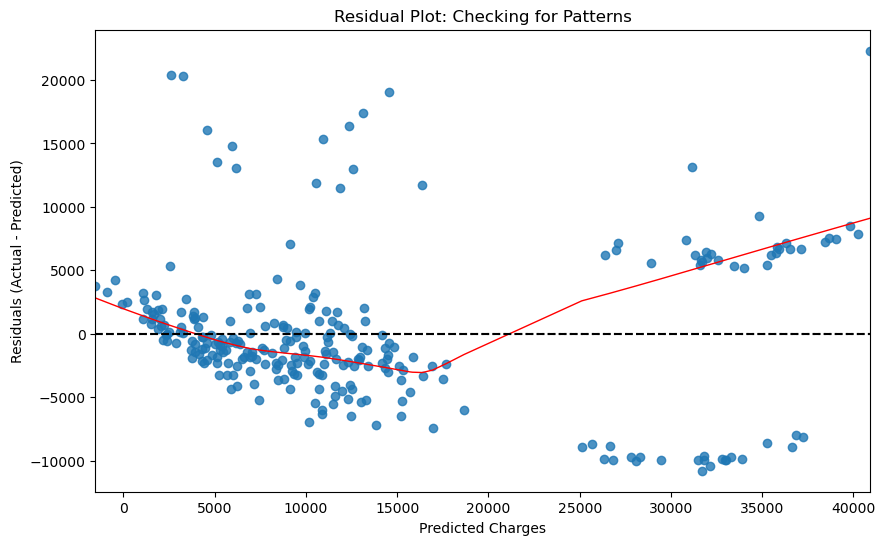

In [40]:
# Calculate residuals
residuals = y_test - predictions

plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 1})

plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Checking for Patterns')
plt.axhline(y=0, color='black', linestyle='--') # Zero line
plt.show()

Summary:
While R2 Score: 0.783 is a very respectable start, our residual plot is telling  that the model is making systematic mistakes at higher costs. The bootom right track is probably for non-smoker cases and the model consisnently over-predicting their costs as they get older or heavier. And the model is under-prediciting costs for smokers(the top right track), because it hasn`t realized how much of a multiplier effect smoking has when combined with other factors

Let`s add the interaction term then!

#### Feature Engineering 

In [42]:
# Create the interaction feature
df['bmi_smoker'] = df['bmi'] * df['smoker']

In [43]:
df

,age,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest,sex_male,bmi_smoker
0,19,27.900,0,1,16884.92400,False,False,True,False,27.90
1,18,33.770,1,0,1725.55230,False,True,False,True,0.00
2,28,33.000,3,0,4449.46200,False,True,False,True,0.00
3,33,22.705,0,0,21984.47061,True,False,False,True,0.00
4,32,28.880,0,0,3866.85520,True,False,False,True,0.00
...,...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,0,10600.54830,True,False,False,True,0.00
1334,18,31.920,0,0,2205.98080,False,False,False,False,0.00
1335,18,36.850,0,0,1629.83350,False,True,False,False,0.00
1336,21,25.800,0,0,2007.94500,False,False,True,False,0.00


In [44]:
# Split Data
X = df.drop('charges', axis=1)
y = df['charges']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Training model

In [45]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Evaluation

In [46]:
predictions = model.predict(X_test)
print(f"R2 Score: {r2_score(y_test, predictions)}")

R2 Score: 0.8652503208873078


Residual Plot

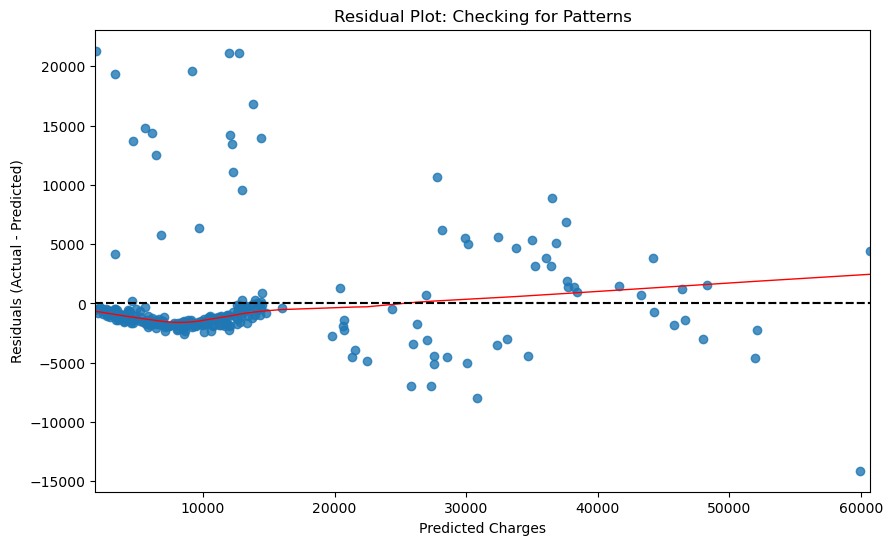

In [47]:
# Calculate residuals
residuals = y_test - predictions

plt.figure(figsize=(10, 6))
sns.residplot(x=predictions, y=residuals, lowess=True, 
              line_kws={'color': 'red', 'lw': 1})

plt.xlabel('Predicted Charges')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot: Checking for Patterns')
plt.axhline(y=0, color='black', linestyle='--') # Zero line
plt.show()

Seeing that $R^2$ jump from 0.783 to 0.865 is a massive improvement! 

#### Interpreting the Coefficients

In [48]:
# View the weights for each feature
importance = pd.DataFrame({'Feature': X.columns, 'Weight': model.coef_})
print(importance.sort_values(by='Weight', ascending=False))

            Feature        Weight
8        bmi_smoker   1470.862534
2          children    463.652623
0               age    263.390620
1               bmi     20.250788
7          sex_male   -525.230854
4  region_northwest   -631.416402
5  region_southeast   -967.480455
6  region_southwest  -1233.426402
3            smoker -21206.908812
